## Month 5 - Project Title: Flight Delay Prediction Using Machine Learning

An airline company wants to predict delays in flights using weather, airline, and route data to improve customer satisfaction.

### Project Objective

* Train a machine learning classification model to predict whether a flight will be delayed or on time.

### Load Dataset
* Airline Delay Dataset (Kaggle)

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import*

In [23]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: kagglehub in c:\users\lenovo\anaconda3\lib\site-packages (0.3.13)



In [24]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download(
    "usdot/flight-delays"
)

print(path)

C:\Users\Lenovo\.cache\kagglehub\datasets\usdot\flight-delays\versions\1


In [25]:
import os

print(os.listdir(path))

['airlines.csv', 'airports.csv', 'flights.csv']


In [27]:
import pandas as pd
import os

flight_path = os.path.join(
    path,
    'flights.csv'
)


df1 = pd.read_csv(
    flight_path,
    nrows=100000
)

print(df1.head())

   YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARRIVAL_DELAY  DIVERTED  CANCELLED  CANCELLATION_REASON  AIR_SYSTEM_DELAY  \
0          -

In [28]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   YEAR                 100000 non-null  int64  
 1   MONTH                100000 non-null  int64  
 2   DAY                  100000 non-null  int64  
 3   DAY_OF_WEEK          100000 non-null  int64  
 4   AIRLINE              100000 non-null  object 
 5   FLIGHT_NUMBER        100000 non-null  int64  
 6   TAIL_NUMBER          99833 non-null   object 
 7   ORIGIN_AIRPORT       100000 non-null  object 
 8   DESTINATION_AIRPORT  100000 non-null  object 
 9   SCHEDULED_DEPARTURE  100000 non-null  int64  
 10  DEPARTURE_TIME       97702 non-null   float64
 11  DEPARTURE_DELAY      97702 non-null   float64
 12  TAXI_OUT             97629 non-null   float64
 13  WHEELS_OFF           97629 non-null   float64
 14  SCHEDULED_TIME       100000 non-null  int64  
 15  ELAPSED_TIME      

# Check the missing value in each column

In [29]:
df1.isnull().sum()

YEAR                       0
MONTH                      0
DAY                        0
DAY_OF_WEEK                0
AIRLINE                    0
FLIGHT_NUMBER              0
TAIL_NUMBER              167
ORIGIN_AIRPORT             0
DESTINATION_AIRPORT        0
SCHEDULED_DEPARTURE        0
DEPARTURE_TIME          2298
DEPARTURE_DELAY         2298
TAXI_OUT                2371
WHEELS_OFF              2371
SCHEDULED_TIME             0
ELAPSED_TIME            2613
AIR_TIME                2613
DISTANCE                   0
WHEELS_ON               2440
TAXI_IN                 2440
SCHEDULED_ARRIVAL          0
ARRIVAL_TIME            2440
ARRIVAL_DELAY           2613
DIVERTED                   0
CANCELLED                  0
CANCELLATION_REASON    97611
AIR_SYSTEM_DELAY       65375
SECURITY_DELAY         65375
AIRLINE_DELAY          65375
LATE_AIRCRAFT_DELAY    65375
WEATHER_DELAY          65375
dtype: int64

* We can clearly see that the dataset sample has lots of columns missing value, some columns have nearly 80 to 90% missing data. so we can directly drop these columns

In [30]:
df1.drop(columns=['CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 
                        'LATE_AIRCRAFT_DELAY','WEATHER_DELAY'], inplace = True, axis=1)

In [32]:
#Droping the column TAIL_Number beacuse it isnot useful in model building
df1.drop(columns = 'TAIL_NUMBER', axis = 1, inplace = True)

In [89]:
#Fill the column TAIL_NUMBER with mode  of the column
#df1_sample['TAIL_NUMBER'] = df1_sample['TAIL_NUMBER'].fillna(df1_sample['TAIL_NUMBER'].mode()[0])

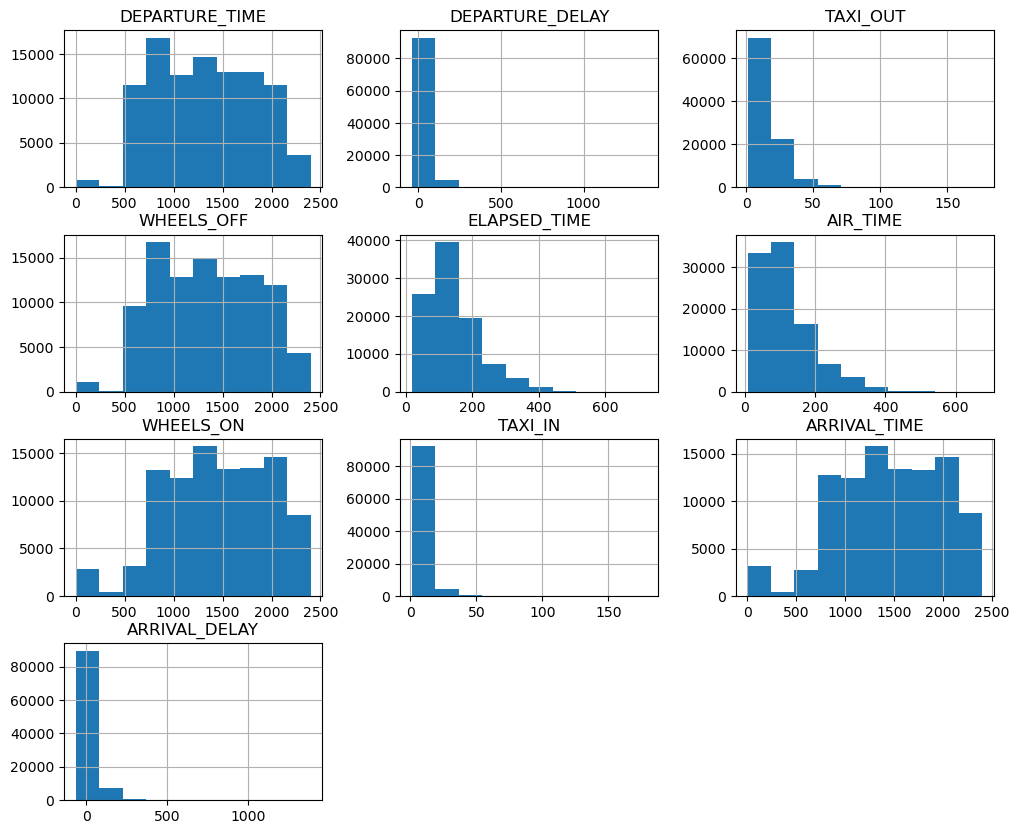

In [36]:
# Distribution
missing_cols=['DEPARTURE_TIME','DEPARTURE_DELAY','TAXI_OUT','WHEELS_OFF','ELAPSED_TIME','AIR_TIME', 'WHEELS_ON','TAXI_IN',
              'ARRIVAL_TIME','ARRIVAL_DELAY']
df1[missing_cols].hist(figsize=(12,10))
plt.show()

In [37]:
# Select numerical columns with missing values
num_cols = df1.select_dtypes(
    include=['int64', 'float64']
).columns

# Keep only columns having missing values
num_missing_cols = [
    col for col in num_cols
    if df1[col].isnull().sum() > 0
]

# Imputation based on skewness
for col in num_missing_cols:
    
    skew_value = df1[col].skew()

    print(f"\nColumn: {col}")
    print(f"Skewness: {skew_value:.2f}")

    # Decision rule
    if abs(skew_value) < 0.5:
        
        # Nearly normal distribution
        mean_value = df1[col].mean()

        df1[col] = df1[col].fillna(mean_value)

        print(f"Filled missing values using MEAN: {mean_value:.2f}")

    else:
        
        # Skewed distribution
        median_value = df1[col].median()

        df1[col] = df1[col].fillna(median_value)

        print(f"Filled missing values using MEDIAN: {median_value:.2f}")


Column: DEPARTURE_TIME
Skewness: 0.05
Filled missing values using MEAN: 1326.27

Column: DEPARTURE_DELAY
Skewness: 5.62
Filled missing values using MEDIAN: 3.00

Column: TAXI_OUT
Skewness: 3.34
Filled missing values using MEDIAN: 14.00

Column: WHEELS_OFF
Skewness: 0.02
Filled missing values using MEAN: 1348.43

Column: ELAPSED_TIME
Skewness: 1.34
Filled missing values using MEDIAN: 125.00

Column: AIR_TIME
Skewness: 1.39
Filled missing values using MEDIAN: 98.00

Column: WHEELS_ON
Skewness: -0.34
Filled missing values using MEAN: 1454.53

Column: TAXI_IN
Skewness: 5.77
Filled missing values using MEDIAN: 6.00

Column: ARRIVAL_TIME
Skewness: -0.38
Filled missing values using MEAN: 1458.03

Column: ARRIVAL_DELAY
Skewness: 4.86
Filled missing values using MEDIAN: 4.00


In [38]:
df1.isnull().sum().sum()

0

In [40]:
#
cat_cols = [
    col for col in df1.columns
    if df1[col].dtype == 'object'
]
print(cat_cols)


le = LabelEncoder()

for col in cat_cols:
    
    # Fill missing values
    df1[col] = df1[col].fillna('Unknown')
    
    # Convert all values to string
    df1[col] = df1[col].astype(str)
    
    # Encode
    df1[col] = le.fit_transform(df1[col])

print("Encoding completed successfully")

['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
Encoding completed successfully


In [41]:
df1['ARRIVAL_DELAY'].describe()

count    100000.000000
mean         17.967540
std          48.289637
min         -65.000000
25%          -8.000000
50%           4.000000
75%          26.000000
max        1384.000000
Name: ARRIVAL_DELAY, dtype: float64

In [44]:
df1['DELAYED'] = (
    df1['ARRIVAL_DELAY'] > 15
).astype(int)

In [129]:
df1_sample.head(2)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,ARRIVAL_DELAY,DIVERTED,CANCELLED,DELAYED
0,2015,2,16,1,0,2206,360,469,1959,2053.0,153.0,2326.0,166.0,919,2245,174.0,0,0,1
1,2015,1,12,1,13,4132,296,459,855,852.0,22.0,914.0,90.0,404,1025,3.0,0,0,0


In [47]:
# Features
X = df1.drop('DELAYED', axis=1)

# Target
y = df1['DELAYED']

In [48]:
#For flight delay prediction, remove columns like:
leakage_cols = [

    # direct leakage
    'ARRIVAL_DELAY',

    # future information
    'ARRIVAL_TIME',
    'WHEELS_ON',
    'WHEELS_OFF',

    # operational after departure
    'AIR_TIME',
    'ELAPSED_TIME',
    'TAXI_IN',
    'TAXI_OUT',

    # very strong leakage
    'DEPARTURE_DELAY'
]

X = X.drop(columns=leakage_cols, errors='ignore')

In [49]:
scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
#model building
lr_model = LogisticRegression(max_iter=1000,
    class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

# Classification report
print(
    classification_report(y_test, y_pred)
)

# Confusion matrix
print(
    confusion_matrix(y_test, y_pred)
)

Accuracy: 0.71605
              precision    recall  f1-score   support

           0       0.83      0.72      0.77     13269
           1       0.56      0.71      0.63      6731

    accuracy                           0.72     20000
   macro avg       0.70      0.71      0.70     20000
weighted avg       0.74      0.72      0.72     20000

[[9574 3695]
 [1984 4747]]


In [55]:
import pickle

# Save model
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

print("Model saved successfully")

Model saved successfully


### RandomFOrest Classification model building

In [65]:
#model building
rf_model = RandomForestClassifier(n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    )
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Accuracy
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

# Classification report
print(
    classification_report(y_test, y_pred)
)

# Confusion matrix
print(
    confusion_matrix(y_test, y_pred)
)

Accuracy: 0.74175
              precision    recall  f1-score   support

           0       0.84      0.75      0.79     13269
           1       0.60      0.73      0.65      6731

    accuracy                           0.74     20000
   macro avg       0.72      0.74      0.72     20000
weighted avg       0.76      0.74      0.75     20000

[[9944 3325]
 [1840 4891]]


In [66]:
import joblib

joblib.dump(
    rf_model,
    'final_random_forest_model.pkl'
)

['final_random_forest_model.pkl']

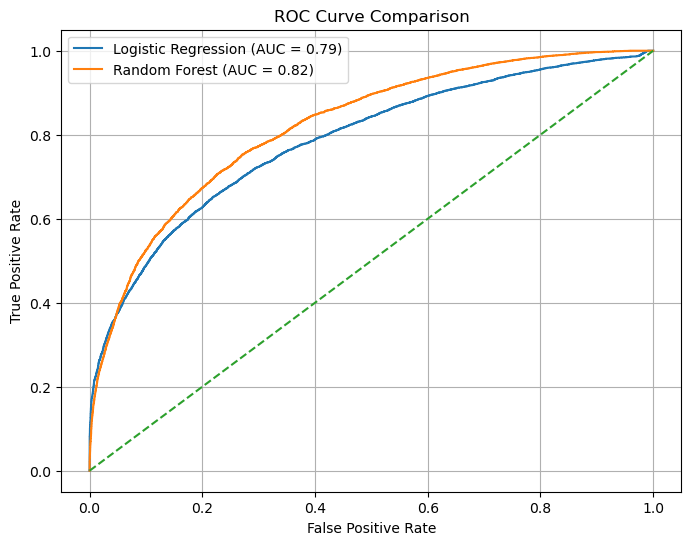

In [67]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_prob_lr = lr_model.predict_proba(
    X_test
)[:, 1]

# Random Forest probabilities
y_prob_rf = rf_model.predict_proba(
    X_test
)[:, 1]

# ROC values for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

roc_auc_lr = auc(
    fpr_lr,
    tpr_lr
)

# ROC values for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

roc_auc_rf = auc(
    fpr_rf,
    tpr_rf
)

# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_rf:.2f})'
)

# Diagonal reference line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()